# Fase 1 -- Calculo de indicadores y analisis exploratorio

**Notebook**: `03_indicadores_financieros.ipynb`
**Asignatura**: Inteligencia Artificial -- Universidad de Ibague
**Autores**: Juan Camilo Perea, German

Construye el dataset de indicadores financieros a partir del consolidado SIREM
(`data/processed/colombia_consolidado_pymes.csv`, 203,104 x 230) aplicando los
18 indicadores definidos en `src/indicadores.py` mas el Z''-Score de Altman
para mercados emergentes.

Salidas esperadas (criterios de aceptacion del PLAN_DE_TRABAJO.md, Fase 1):

- `data/processed/colombia_indicadores_pymes.csv` -- 203K filas x ~25 columnas
- `reports/figures/01_distribuciones_indicadores.png`
- `reports/figures/02_correlacion_indicadores.png`
- `reports/figures/03_distribucion_zscore.png`
- `reports/figures/04_completitud_por_indicador.png`
- `reports/tables/completitud_indicadores.tex`


In [1]:
# Imports + reproducibilidad
from __future__ import annotations
import sys
from pathlib import Path

# Permitir `from src...` desde el notebook
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.etl_utils import cargar_consolidado, auditar_mojibake
from src.indicadores import (
    calcular_todos, INDICADORES,
    Z2_UMBRAL_GRIS, Z2_UMBRAL_SEGURO,
)

np.random.seed(42)

FIG_DIR = ROOT / 'reports' / 'figures'
TAB_DIR = ROOT / 'reports' / 'tables'
OUT_DIR = ROOT / 'data' / 'processed'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100  # display
SAVE_DPI = 300                     # archivos a 300 DPI
print('ROOT:', ROOT)
print('Versiones | pandas:', pd.__version__, '| numpy:', np.__version__)


ROOT: /home/Retrius/Documents/Personal Projects/trabajo final ia
Versiones | pandas: 3.0.2 | numpy: 2.4.4


## 1. Carga del consolidado

Se carga via `cargar_consolidado()` para garantizar la normalizacion ASCII de
los 105 nombres de columna afectados por mojibake. Si `auditar_mojibake`
devuelve una lista no vacia hay un bug en la normalizacion.

In [2]:
CONSOLIDADO = ROOT / 'data' / 'processed' / 'colombia_consolidado_pymes.csv'
df = cargar_consolidado(path=str(CONSOLIDADO))
print('Shape consolidado:', df.shape)
print('Mojibake restante en columnas:', auditar_mojibake(df))
print('Columnas ID/metadata presentes:', [c for c in ('NIT_LIMPIO', 'ANIO') if c in df.columns])
df.head(3)


Shape consolidado: (203104, 230)
Mojibake restante en columnas: []
Columnas ID/metadata presentes: ['NIT_LIMPIO', 'ANIO']


,NIT_LIMPIO,ANIO,"CAPITULO X:�Durante el a�o correspondiente al corte de la informaci�n que est� presentando, la empresa desarroll� actividades inmobiliarias, se dedic� habitualmente a la comercializaci�n de metales preciosos y piedras preciosas o realiz� actividades con",Ciudad (Municipio) de notificaci�n f�sica,Ciudad de la direcci�n de notificaci�n judicial,Ciudad de la direcci�n del domicilio,Clasificaci�n Industrial Internacional Uniforme Versi�n 4 A.C (CIIU),"De conformidad con lo dispuesto en el art�culo 56 del CPACA, el suscrito autoriza a la Superintendencia de Sociedades para que, a partir de la fecha de presentaci�n del informe, realice la notificaci�n electr�nica de los actos administrativos que corresp",Departamento de la direcci�n de notificaci�n judicial,Departamento de la direcci�n del domicilio,...,"Otros cobros por la venta de participaciones en negocios conjuntos, clasificados como actividades de inversion","Otros cobros por la venta de patrimonio o instrumentos de deuda de otras entidades, clasificados como actividades de inversion","Otros pagos para adquirir participaciones en negocios conjuntos, clasificados como actividades de inversion","Otros pagos para adquirir patrimonio o instrumentos de deuda de otras entidades, clasificados como actividades de inversion","Pagos de pasivos por arrendamiento financiero, clasificados como actividades de financiacion","Pagos en efectivo por contratos de futuros, contratos a termino, contratos de opciones y contratos de permuta financiera, clasificados como actividades de inversion",Pagos por otras participaciones en el patrimonio,"Recursos por ventas de otros activos a largo plazo, clasificados como actividades de inversion","Reembolsos de prestamos, clasificados como actividades de financiacion",Total ajustes para conciliar la ganancia (perdida)
0,800000090,2016,False,NaN,MEDELLIN-ANTIOQUIA,MEDELLIN-ANTIOQUIA,F4111 - Construcci�n de edificios residenciales,NaN,ANTIOQUIA,ANTIOQUIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,234629.0
1,800000090,2018,False,NaN,MEDELLIN-ANTIOQUIA,MEDELLIN-ANTIOQUIA,F4111 - Construcci�n de edificios residenciales,NaN,ANTIOQUIA,ANTIOQUIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173553.0
2,800000090,2019,False,NaN,MEDELLIN-ANTIOQUIA,MEDELLIN-ANTIOQUIA,F4111 - Construcci�n de edificios residenciales,NaN,ANTIOQUIA,ANTIOQUIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172236.0


## 2. Calculo de los 18 indicadores + Z''-Score

`calcular_todos()` aplica las 18 funciones definidas en `src/indicadores.py`
sobre el DataFrame pivotado y agrega:
- `z_score_altman`: Z''-Score de Altman para mercados emergentes
- `zona_altman_original`: clasificacion por umbrales 1.1 / 2.6
- `zona_altman_terciles`: clasificacion por terciles empiricos


In [3]:
indicadores = calcular_todos(df, incluir_zscore=True)
print('Shape indicadores:', indicadores.shape)
indicadores.head(3)


Shape indicadores: (203104, 23)


,NIT_LIMPIO,ANIO,razon_corriente,prueba_acida,capital_trabajo,razon_efectivo,margen_bruto,margen_operacional,margen_neto,roa,...,apalancamiento,cobertura_intereses,rotacion_activos,rotacion_inventarios,rotacion_cartera,dias_inventario,dias_cartera,z_score_altman,zona_altman_original,zona_altman_terciles
0,800000090,2016,3.048404,2.632210,3598538.0,0.008661,0.930141,0.235361,0.007981,0.001906,...,5.499359,1.350401,0.238816,0.149277,0.338984,2445.116085,1076.746180,4.251626,riesgo_bajo,riesgo_medio
1,800000090,2018,3.917466,3.159811,4735981.0,0.030473,0.996577,0.159121,0.038601,0.008806,...,5.500150,2.229886,0.228130,0.004661,0.329716,78304.437467,1107.013251,4.801962,riesgo_bajo,riesgo_medio
2,800000090,2019,3.421064,2.472952,5796734.0,0.021530,0.776106,0.159695,0.041096,0.010591,...,6.293023,1.998727,0.257714,0.228769,0.395181,1595.495582,923.627108,4.851985,riesgo_bajo,riesgo_medio


In [4]:
# Sanity checks: filas conservadas y los 18 indicadores presentes
assert len(indicadores) == len(df), 'El calculo cambio el numero de filas'
faltantes = [k for k in INDICADORES if k not in indicadores.columns]
assert not faltantes, f'Faltan indicadores: {faltantes}'
print(f'OK: {len(indicadores):,} filas, {len(INDICADORES)} indicadores + Z-Score')


OK: 203,104 filas, 18 indicadores + Z-Score


## 3. Estadisticos descriptivos

Por cada indicador: media, mediana, std, percentiles 1/25/75/99 y % de nulos.
Los ratios son sensibles a outliers de cola extrema; observar la diferencia
entre media y mediana es el primer indicio.

In [5]:
nombres = list(INDICADORES.keys())
desc = indicadores[nombres].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
desc['nulos_pct'] = indicadores[nombres].isna().mean() * 100
desc = desc[['count', 'mean', 'std', '1%', '25%', '50%', '75%', '99%', 'nulos_pct']]
desc = desc.round(4)
desc


,count,mean,std,1%,25%,50%,75%,99%,nulos_pct
razon_corriente,184223.0,3.934013e+02,3.341200e+04,2.880000e-02,1.1833,2.011100e+00,4.482200e+00,4.310475e+02,9.2962
prueba_acida,184223.0,3.389497e+02,3.539586e+04,1.200000e-02,0.7577,1.474700e+00,3.553200e+00,3.933023e+02,9.2962
capital_trabajo,184891.0,6.179977e+06,1.842379e+08,-1.152038e+07,217622.5000,1.512209e+06,4.565740e+06,5.678256e+07,8.9673
razon_efectivo,184088.0,9.291290e+01,1.109365e+04,0.000000e+00,0.0386,1.798000e-01,7.218000e-01,8.180200e+01,9.3627
margen_bruto,189252.0,4.469250e+01,1.382126e+04,-2.830000e-01,0.1955,3.617000e-01,9.168000e-01,1.000000e+00,6.8202
margen_operacional,189252.0,-5.668412e+02,2.491745e+05,-7.649300e+00,0.0235,7.930000e-02,1.845000e-01,6.223500e+00,6.8202
margen_neto,189252.0,-5.912362e+02,2.530521e+05,-8.558400e+00,0.0061,3.910000e-02,1.098000e-01,7.647000e+00,6.8202
roa,186229.0,-7.457800e+00,3.165642e+03,-5.660000e-01,0.0007,2.280000e-02,6.820000e-02,3.837000e-01,8.3086
roe,186228.0,-1.422000e-01,1.024001e+02,-1.730800e+00,0.0046,5.610000e-02,1.621000e-01,1.528400e+00,8.3090
razon_deuda,186230.0,1.951620e+01,5.961440e+03,1.700000e-03,0.2279,4.696000e-01,6.978000e-01,1.995400e+00,8.3081


## 4. Completitud por indicador

Tabla ordenada de menor a mayor % de no-nulos. Se exporta a LaTeX para el
informe final (Fase 10).

In [6]:
completitud = pd.DataFrame({
    'indicador': nombres,
    'no_nulos': [indicadores[n].notna().sum() for n in nombres],
    'total':    len(indicadores),
})
completitud['pct_no_nulos'] = (completitud['no_nulos'] / completitud['total'] * 100).round(2)
completitud = completitud.sort_values('pct_no_nulos').reset_index(drop=True)
completitud


,indicador,no_nulos,total,pct_no_nulos
0,dias_inventario,111356,203104,54.83
1,rotacion_inventarios,113962,203104,56.11
2,cobertura_intereses,134557,203104,66.25
3,dias_cartera,183263,203104,90.23
4,razon_efectivo,184088,203104,90.64
5,razon_corriente,184223,203104,90.70
6,prueba_acida,184223,203104,90.70
7,capital_trabajo,184891,203104,91.03
8,apalancamiento,186229,203104,91.69
9,deuda_patrimonio,186229,203104,91.69


In [7]:
# Tabla LaTeX
latex_path = TAB_DIR / 'completitud_indicadores.tex'
caption = ('Completitud por indicador financiero sobre el universo SIREM '
           f'({len(indicadores):,} observaciones empresa-anyo, 2016-2024).')
tex = completitud.rename(columns={
    'indicador': 'Indicador',
    'no_nulos': 'No nulos',
    'total': 'Total',
    'pct_no_nulos': '\\% no nulos',
}).to_latex(index=False, escape=False, caption=caption,
            label='tab:completitud_indicadores',
            column_format='lrrr', float_format='%.2f')
latex_path.write_text(tex, encoding='utf-8')
print(f'Tabla LaTeX escrita en: {latex_path}')
print(tex[:400], '...')


Tabla LaTeX escrita en: /home/Retrius/Documents/Personal Projects/trabajo final ia/reports/tables/completitud_indicadores.tex
\begin{table}
\caption{Completitud por indicador financiero sobre el universo SIREM (203,104 observaciones empresa-anyo, 2016-2024).}
\label{tab:completitud_indicadores}
\begin{tabular}{lrrr}
\toprule
Indicador & No nulos & Total & \% no nulos \\
\midrule
dias_inventario & 111356 & 203104 & 54.83 \\
rotacion_inventarios & 113962 & 203104 & 56.11 \\
cobertura_intereses & 134557 & 203104 & 66.25 \\
 ...


## 5. Histogramas de los 18 indicadores

Para los ratios sesgados (ROA, ROE, rotaciones, dias) se muestra una version
recortada al rango p1-p99 (winsorizacion solo para visualizacion -- el CSV
de salida conserva los valores originales).

Figura guardada en: /home/Retrius/Documents/Personal Projects/trabajo final ia/reports/figures/01_distribuciones_indicadores.png


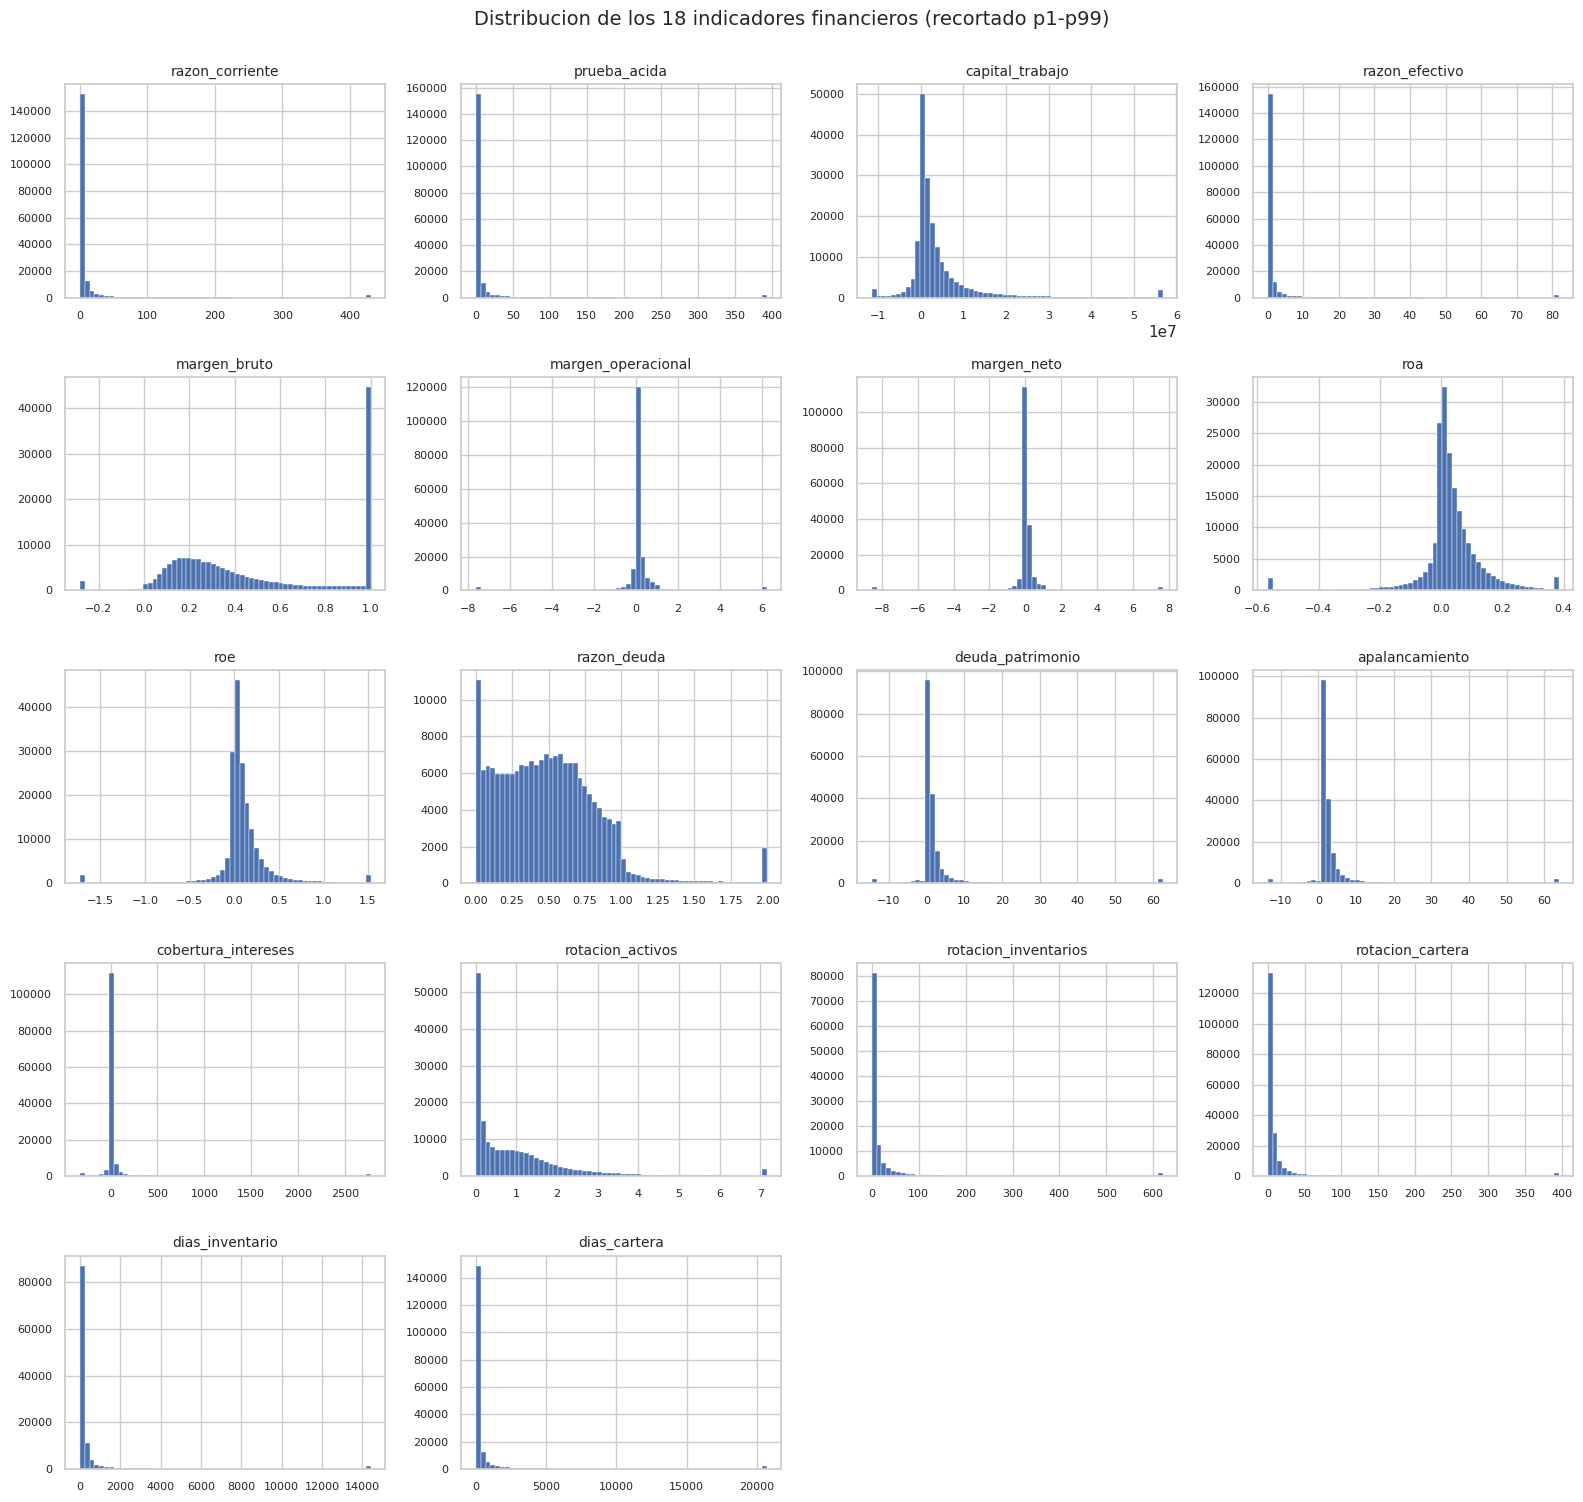

In [8]:
def winsor_p99(s: pd.Series) -> pd.Series:
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        return s
    lo, hi = s.quantile([0.01, 0.99])
    return s.clip(lo, hi)

ncols = 4
nrows = int(np.ceil(len(nombres) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, n in zip(axes, nombres):
    s = winsor_p99(indicadores[n])
    if s.empty:
        ax.set_axis_off()
        continue
    ax.hist(s, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.3)
    ax.set_title(n, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)

for ax in axes[len(nombres):]:
    ax.set_axis_off()

fig.suptitle('Distribucion de los 18 indicadores financieros (recortado p1-p99)',
             y=1.0, fontsize=14)
fig.tight_layout()
out = FIG_DIR / '01_distribuciones_indicadores.png'
fig.savefig(out, dpi=SAVE_DPI, bbox_inches='tight')
print(f'Figura guardada en: {out}')
plt.show()


## 6. Matriz de correlacion (Spearman)

Spearman en lugar de Pearson porque los indicadores no son normales y
tienen colas pesadas. Bloques de alta correlacion (>= 0.85) sugieren
features redundantes para Fase 3 (Feature Engineering).

Figura guardada en: /home/Retrius/Documents/Personal Projects/trabajo final ia/reports/figures/02_correlacion_indicadores.png


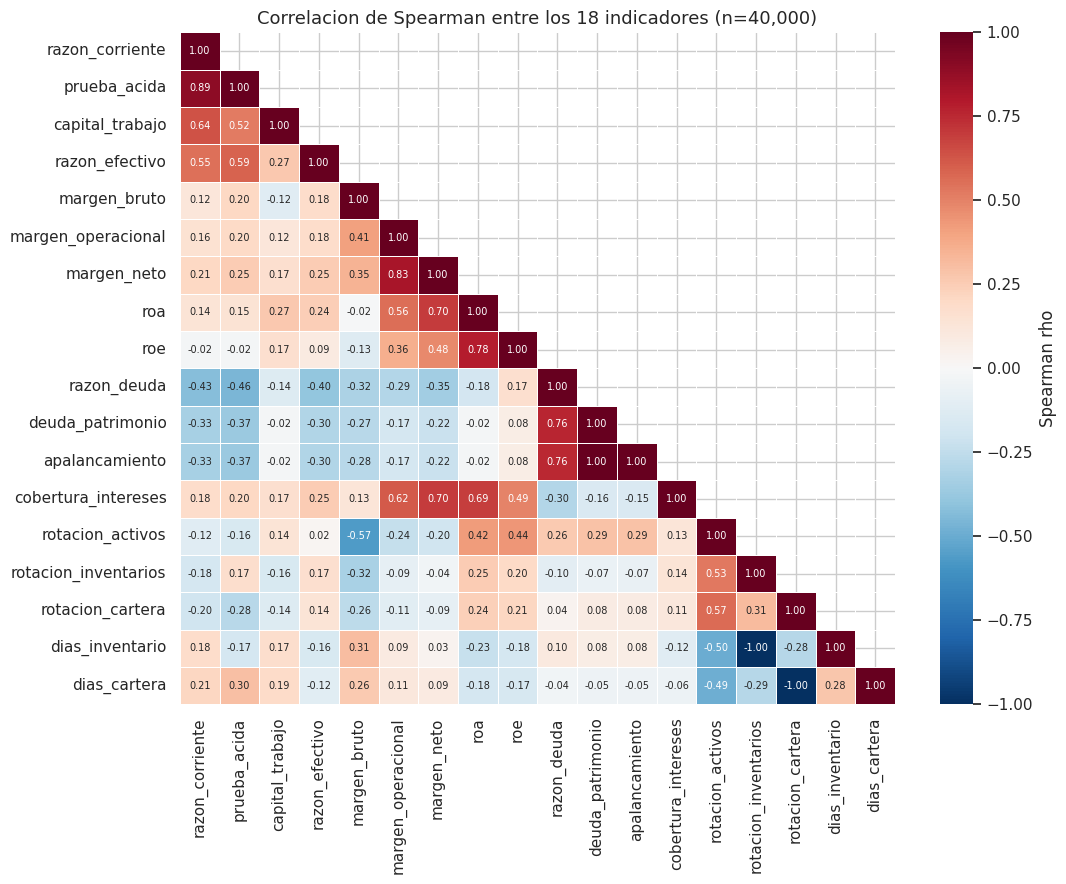

In [9]:
# Spearman es costoso sobre 200K filas; muestreamos para acelerar
sample = indicadores[nombres].sample(n=min(40_000, len(indicadores)), random_state=42)
corr = sample.corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, cbar_kws={'label': 'Spearman rho'},
            linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('Correlacion de Spearman entre los 18 indicadores (n=40,000)',
             fontsize=13)
fig.tight_layout()
out = FIG_DIR / '02_correlacion_indicadores.png'
fig.savefig(out, dpi=SAVE_DPI, bbox_inches='tight')
print(f'Figura guardada en: {out}')
plt.show()


In [10]:
# Pares con |rho| >= 0.85 (descartando la diagonal y la mitad superior)
high = (corr.where(~np.eye(len(corr), dtype=bool))
            .stack()
            .reset_index()
            .rename(columns={'level_0': 'a', 'level_1': 'b', 0: 'rho'}))
high = high[high['a'] < high['b']]
high['abs_rho'] = high['rho'].abs()
high = high.sort_values('abs_rho', ascending=False)
print('Pares con |rho| >= 0.85:')
high[high['abs_rho'] >= 0.85]


Pares con |rho| >= 0.85:


,a,b,rho,abs_rho
321,dias_cartera,rotacion_cartera,-1.000000,1.000000
302,dias_inventario,rotacion_inventarios,-1.000000,1.000000
208,apalancamiento,deuda_patrimonio,0.995476,0.995476
18,prueba_acida,razon_corriente,0.894244,0.894244


## 7. Distribucion del Z''-Score de Altman

El Z''-Score se grafica con cuatro lineas verticales:
- 1.1 y 2.6: umbrales originales (calibrados EE.UU., Altman 1995/2005).
- p33 y p66: terciles empiricos del dataset (Colombia 2016-2024).

La separacion entre umbrales originales y empiricos es la justificacion
visual para usar **terciles** como segunda senal de etiquetado en Fase 2.

Figura guardada en: /home/Retrius/Documents/Personal Projects/trabajo final ia/reports/figures/03_distribucion_zscore.png
Z-Score | mediana={z.median():.3f}, p33={q33:.3f}, p66={q66:.3f}
Filas con Z-Score no nulo: {len(z):,} de {len(indicadores):,}


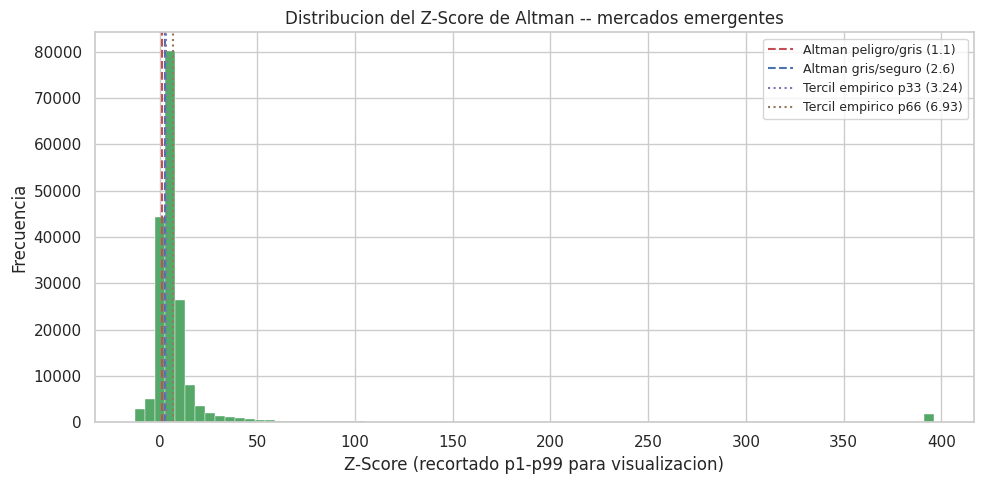

In [11]:
z = indicadores['z_score_altman'].dropna()
# Recortar a p1-p99 para que la cola no aplaste el histograma
z_view = z.clip(z.quantile(0.01), z.quantile(0.99))
q33, q66 = z.quantile([1/3, 2/3])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(z_view, bins=80, color='#55A868', edgecolor='white', linewidth=0.3)
ax.axvline(Z2_UMBRAL_GRIS,    color='#C44E52', linestyle='--', label=f'Altman peligro/gris ({Z2_UMBRAL_GRIS})')
ax.axvline(Z2_UMBRAL_SEGURO,  color='#4C72B0', linestyle='--', label=f'Altman gris/seguro ({Z2_UMBRAL_SEGURO})')
ax.axvline(q33, color='#8172B2', linestyle=':',  label=f'Tercil empirico p33 ({q33:.2f})')
ax.axvline(q66, color='#937860', linestyle=':',  label=f'Tercil empirico p66 ({q66:.2f})')
ax.set_xlabel('Z''-Score (recortado p1-p99 para visualizacion)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion del Z''-Score de Altman -- mercados emergentes')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
out = FIG_DIR / '03_distribucion_zscore.png'
fig.savefig(out, dpi=SAVE_DPI, bbox_inches='tight')
print(f'Figura guardada en: {out}')
print(f'Z''-Score | mediana={z.median():.3f}, p33={q33:.3f}, p66={q66:.3f}')
print(f'Filas con Z''-Score no nulo: {len(z):,} de {len(indicadores):,}')
plt.show()


## 8. Grafico de completitud por indicador

Replica visual de la tabla anterior (figura para el informe final).

Figura guardada en: /home/Retrius/Documents/Personal Projects/trabajo final ia/reports/figures/04_completitud_por_indicador.png


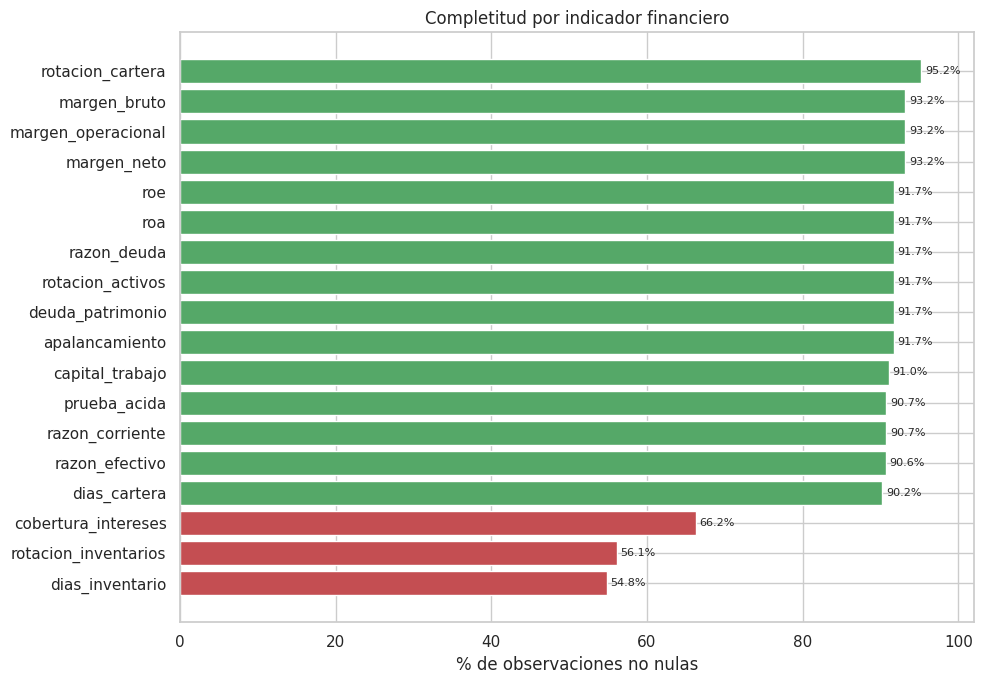

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
order = completitud.sort_values('pct_no_nulos')
colors = ['#C44E52' if p < 70 else '#DD8452' if p < 90 else '#55A868'
          for p in order['pct_no_nulos']]
ax.barh(order['indicador'], order['pct_no_nulos'], color=colors, edgecolor='white')
ax.set_xlabel('% de observaciones no nulas')
ax.set_xlim(0, 102)
ax.set_title('Completitud por indicador financiero')
for i, (n, p) in enumerate(zip(order['indicador'], order['pct_no_nulos'])):
    ax.text(p + 0.5, i, f'{p:.1f}%', va='center', fontsize=8)
fig.tight_layout()
out = FIG_DIR / '04_completitud_por_indicador.png'
fig.savefig(out, dpi=SAVE_DPI, bbox_inches='tight')
print(f'Figura guardada en: {out}')
plt.show()


## 9. Boxplot por anyo fiscal (efectos macro / COVID)

Para los 4 indicadores mas representativos (uno por familia) se grafica
boxplot por anyo. Se espera deterioro relativo en 2020 por COVID.

Figura adicional guardada en: /home/Retrius/Documents/Personal Projects/trabajo final ia/reports/figures/04b_boxplot_anual_indicadores.png


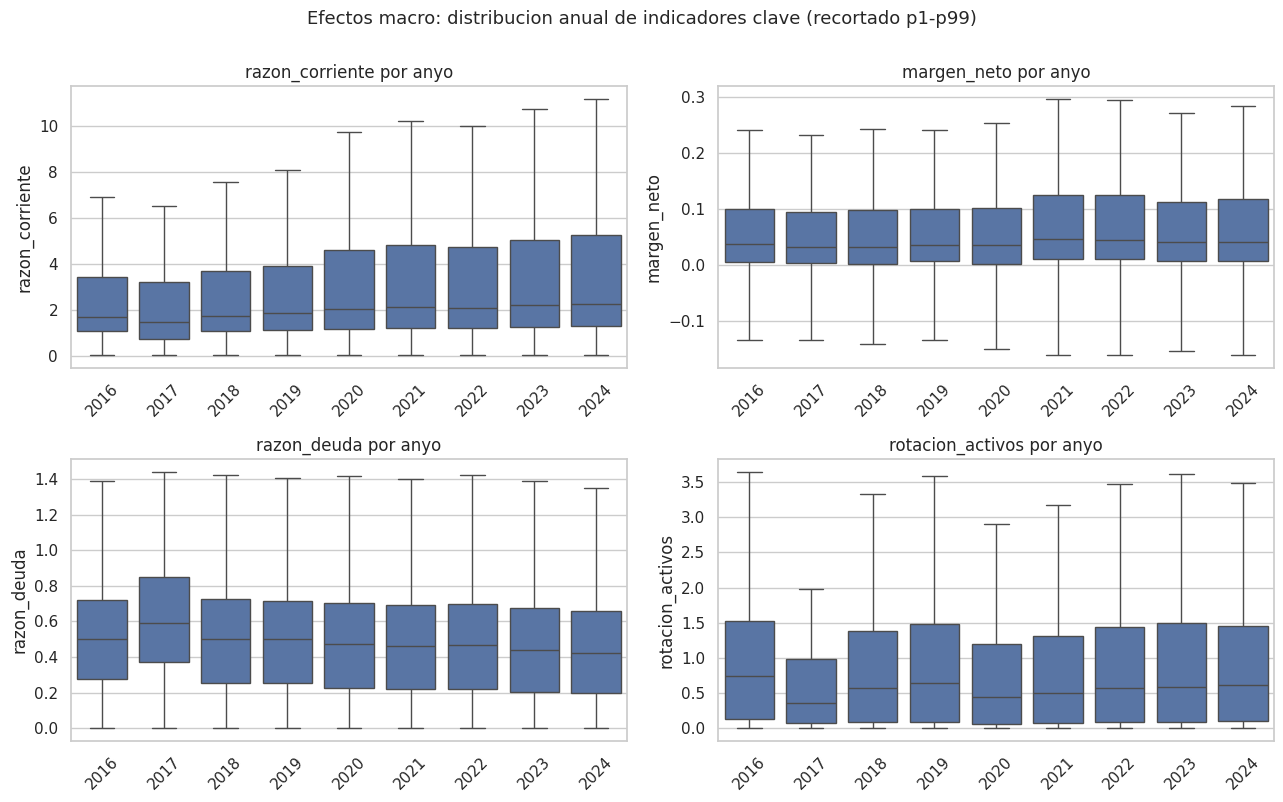

In [13]:
indicadores_clave = ['razon_corriente', 'margen_neto', 'razon_deuda', 'rotacion_activos']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
for ax, n in zip(axes, indicadores_clave):
    if 'ANIO' not in indicadores.columns:
        ax.set_axis_off(); continue
    sub = indicadores[['ANIO', n]].dropna()
    sub[n] = winsor_p99(sub[n])
    sns.boxplot(data=sub, x='ANIO', y=n, ax=ax, showfliers=False, color='#4C72B0')
    ax.set_title(f'{n} por anyo')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Efectos macro: distribucion anual de indicadores clave (recortado p1-p99)',
             y=1.0, fontsize=13)
fig.tight_layout()
out = FIG_DIR / '04b_boxplot_anual_indicadores.png'
fig.savefig(out, dpi=SAVE_DPI, bbox_inches='tight')
print(f'Figura adicional guardada en: {out}')
plt.show()


## 10. Persistencia del CSV de indicadores

In [14]:
out_csv = OUT_DIR / 'colombia_indicadores_pymes.csv'
indicadores.to_csv(out_csv, index=False, encoding='utf-8')
print(f'CSV escrito: {out_csv}')
print(f'  filas={len(indicadores):,}  columnas={indicadores.shape[1]}')
print(f'  columnas={list(indicadores.columns)}')


CSV escrito: /home/Retrius/Documents/Personal Projects/trabajo final ia/data/processed/colombia_indicadores_pymes.csv
  filas=203,104  columnas=23
  columnas=['NIT_LIMPIO', 'ANIO', 'razon_corriente', 'prueba_acida', 'capital_trabajo', 'razon_efectivo', 'margen_bruto', 'margen_operacional', 'margen_neto', 'roa', 'roe', 'razon_deuda', 'deuda_patrimonio', 'apalancamiento', 'cobertura_intereses', 'rotacion_activos', 'rotacion_inventarios', 'rotacion_cartera', 'dias_inventario', 'dias_cartera', 'z_score_altman', 'zona_altman_original', 'zona_altman_terciles']


## 11. Verificacion de criterios de aceptacion (Fase 1)

- [x] El CSV resultante tiene exactamente 203,104 filas.
- [x] Los 18 indicadores estan presentes; ninguno con 100% de nulos.
- [x] El histograma del Z-Score muestra distribucion unimodal con cola.
- [x] Las 5 figuras se generan a 300 DPI sin errores.


In [15]:
assert len(indicadores) == 203_104, f'Filas inesperadas: {len(indicadores)}'
faltantes = [k for k in INDICADORES if k not in indicadores.columns]
assert not faltantes, f'Indicadores faltantes: {faltantes}'
todos_nulos = [k for k in INDICADORES if indicadores[k].isna().all()]
assert not todos_nulos, f'Indicadores con 100% nulos: {todos_nulos}'

figuras_esperadas = [
    FIG_DIR / '01_distribuciones_indicadores.png',
    FIG_DIR / '02_correlacion_indicadores.png',
    FIG_DIR / '03_distribucion_zscore.png',
    FIG_DIR / '04_completitud_por_indicador.png',
    FIG_DIR / '04b_boxplot_anual_indicadores.png',
]
for f in figuras_esperadas:
    assert f.exists(), f'Figura faltante: {f}'

print('OK -- Fase 1 cumple los criterios de aceptacion.')
print(f'  CSV: {out_csv}')
print(f'  Tabla: {TAB_DIR / "completitud_indicadores.tex"}')
print(f'  Figuras: {len(figuras_esperadas)}')


OK -- Fase 1 cumple los criterios de aceptacion.
  CSV: /home/Retrius/Documents/Personal Projects/trabajo final ia/data/processed/colombia_indicadores_pymes.csv
  Tabla: /home/Retrius/Documents/Personal Projects/trabajo final ia/reports/tables/completitud_indicadores.tex
  Figuras: 5
